# Cryptocurrency Market Analysis

**Data Source:** [CoinGecko API](https://www.coingecko.com/en/api) - Real-time cryptocurrency market data

**Objective:** Analyze the crypto market structure, dominance patterns, price performance, and volatility across the top 250 cryptocurrencies.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12,6), 'axes.titlesize': 14, 'axes.titleweight': 'bold'})

In [2]:
df = pd.read_csv('../data/crypto_market.csv')

# Clean numeric columns
num_cols = ['current_price','market_cap','total_volume','high_24h','low_24h',
            'price_change_24h','price_change_pct_24h','market_cap_change_pct_24h',
            'circulating_supply','ath','ath_change_pct','atl']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=['market_cap']).sort_values('market_cap', ascending=False).reset_index(drop=True)
print(f'Coins loaded: {len(df)}')
print(f'Total market cap: ${df["market_cap"].sum()/1e12:.2f}T')
df.head(10)

Coins loaded: 250
Total market cap: $2.36T


,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_24h,price_change_pct_24h,market_cap_change_pct_24h,circulating_supply,total_supply,ath,ath_change_pct,ath_date,atl,atl_date
0,bitcoin,btc,Bitcoin,66537.000000,1331803812962,1,4.058975e+10,68019.000000,65112.000000,37.170000,0.05589,0.21456,2.000923e+07,2.000923e+07,126080.000000,-47.22657,2025-10-06,67.810000,2013-07-06
1,ethereum,eth,Ethereum,2022.920000,244241270337,2,1.808773e+10,2077.320000,1947.320000,25.330000,1.26806,1.34623,1.206914e+08,1.206914e+08,4946.050000,-59.10032,2025-08-24,0.432979,2015-10-20
2,tether,usdt,Tether,0.999127,184062144082,3,6.470406e+10,0.999348,0.999049,-0.000065,-0.00650,-0.00491,1.842220e+11,1.896889e+11,1.320000,-24.48708,2018-07-24,0.572521,2015-03-02
3,binancecoin,bnb,BNB,609.660000,83265223628,4,1.038045e+09,620.050000,598.480000,-0.338942,-0.05556,0.14387,1.363572e+08,1.363572e+08,1369.990000,-55.49887,2025-10-13,0.039818,2017-10-19
4,ripple,xrp,XRP,1.320000,81088648970,5,2.044975e+09,1.360000,1.310000,0.002982,0.22597,0.20106,6.134458e+10,9.998570e+10,3.650000,-63.73114,2025-07-18,0.002686,2014-05-22
5,usd-coin,usdc,USDC,0.999611,77417634484,6,4.673050e+09,0.999840,0.999577,-0.000155,-0.01548,-0.38711,7.744774e+10,7.750217e+10,1.043000,-4.20624,2018-11-15,0.877647,2023-03-11
6,solana,sol,Solana,82.640000,47312092773,7,3.769924e+09,84.690000,79.810000,0.905786,1.10818,1.11687,5.724950e+08,5.724950e+08,293.310000,-71.82453,2025-01-19,0.500801,2020-05-11
7,tron,trx,TRON,0.319367,30268798772,8,7.067223e+08,0.324259,0.316608,-0.003572,-1.10598,-0.75384,9.476279e+10,9.476286e+10,0.431288,-25.95050,2024-12-04,0.001804,2017-11-12
8,figure-heloc,figr_heloc,Figure Heloc,1.029000,16729923658,9,7.872849e+07,1.029000,1.000000,0.029316,2.93155,2.93155,1.625345e+10,1.625345e+10,1.049000,-1.88683,2026-03-09,0.155357,2025-10-31
9,dogecoin,doge,Dogecoin,0.090950,13958675785,10,1.266528e+09,0.093521,0.089012,0.000182,0.20089,0.16472,1.536266e+11,1.693394e+11,0.731578,-87.56804,2021-05-08,0.000087,2015-05-06


## 2. Market Overview

In [3]:
total_mcap = df['market_cap'].sum()
total_vol = df['total_volume'].sum()
btc_dom = df[df['symbol']=='btc']['market_cap'].values[0] / total_mcap * 100
eth_dom = df[df['symbol']=='eth']['market_cap'].values[0] / total_mcap * 100 if 'eth' in df['symbol'].values else 0

print(f'Total Market Cap:    ${total_mcap/1e12:.2f} Trillion')
print(f'24h Trading Volume:  ${total_vol/1e9:.1f} Billion')
print(f'BTC Dominance:       {btc_dom:.1f}%')
print(f'ETH Dominance:       {eth_dom:.1f}%')
print(f'Top 10 Dominance:    {df.head(10)["market_cap"].sum()/total_mcap*100:.1f}%')
print(f'Coins tracked:       {len(df)}')

Total Market Cap:    $2.36 Trillion
24h Trading Volume:  $148.6 Billion
BTC Dominance:       56.5%
ETH Dominance:       10.4%
Top 10 Dominance:    89.6%
Coins tracked:       250


## 3. Market Dominance

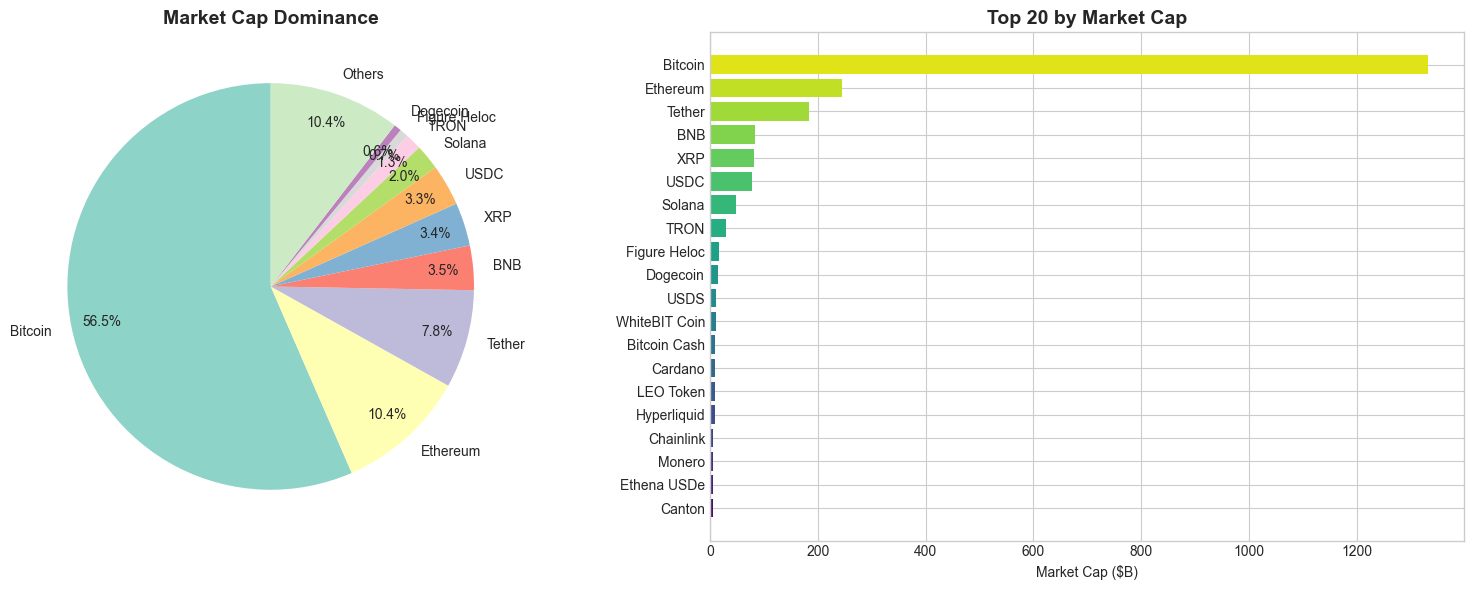

In [4]:
top10 = df.head(10).copy()
others = pd.DataFrame({'name': ['Others'], 'market_cap': [total_mcap - top10['market_cap'].sum()]})
pie_data = pd.concat([top10[['name','market_cap']], others], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

colors = sns.color_palette('Set3', len(pie_data))
axes[0].pie(pie_data['market_cap'], labels=pie_data['name'], autopct='%1.1f%%',
            startangle=90, colors=colors, pctdistance=0.85)
axes[0].set_title('Market Cap Dominance')

top20 = df.head(20)
axes[1].barh(top20['name'][::-1], top20['market_cap'][::-1]/1e9,
             color=sns.color_palette('viridis', 20))
axes[1].set_xlabel('Market Cap ($B)'); axes[1].set_title('Top 20 by Market Cap')

plt.tight_layout()
plt.savefig('../outputs/market_dominance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Price Performance (24h)

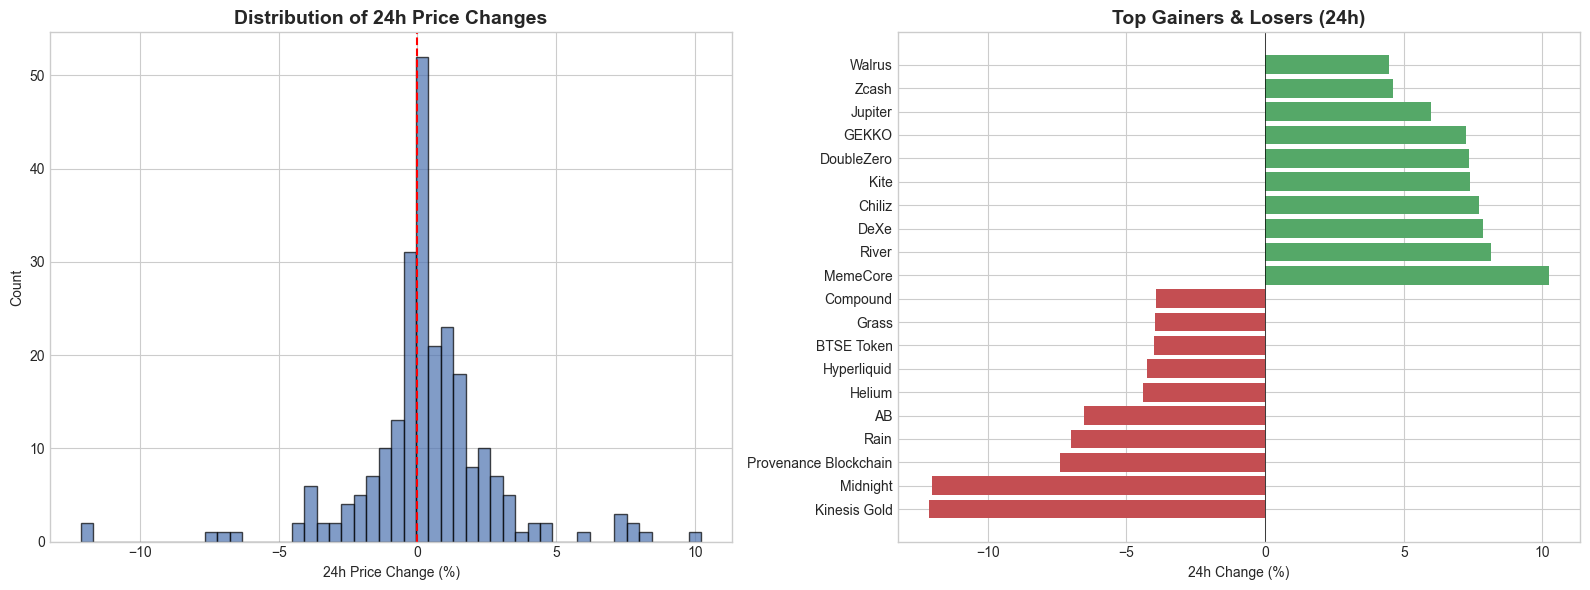

In [5]:
# Price change distribution
# Exclude stablecoins from volatility analysis (they're pegged)
stablecoins = ['tether', 'usd-coin', 'dai', 'trueusd', 'first-digital-usd']
valid = df[~df['id'].isin(stablecoins)].dropna(subset=['price_change_pct_24h'])

fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].hist(valid['price_change_pct_24h'].clip(-20, 20), bins=50,
             color='#4C72B0', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='red', ls='--')
axes[0].set_xlabel('24h Price Change (%)'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of 24h Price Changes')

# Top gainers and losers
top_gain = valid.nlargest(10, 'price_change_pct_24h')[['name','symbol','price_change_pct_24h','current_price']]
top_loss = valid.nsmallest(10, 'price_change_pct_24h')[['name','symbol','price_change_pct_24h','current_price']]
combined = pd.concat([top_loss, top_gain])
colors = ['#C44E52' if x < 0 else '#55A868' for x in combined['price_change_pct_24h']]
axes[1].barh(combined['name'], combined['price_change_pct_24h'], color=colors)
axes[1].set_xlabel('24h Change (%)'); axes[1].set_title('Top Gainers & Losers (24h)')
axes[1].axvline(x=0, color='black', lw=0.5)

plt.tight_layout()
plt.savefig('../outputs/price_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Volume vs Market Cap

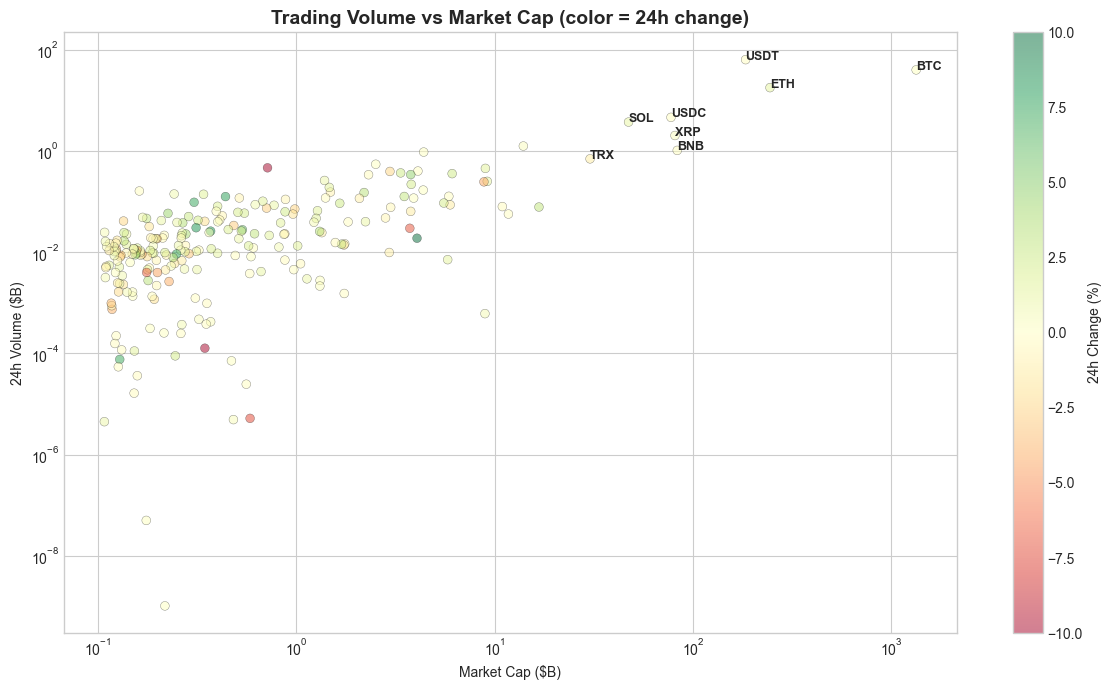

In [6]:
fig, ax = plt.subplots(figsize=(12,7))
valid2 = df.dropna(subset=['total_volume','market_cap'])
valid2 = valid2[valid2['market_cap'] > 0]
valid2['vol_mcap_ratio'] = valid2['total_volume'] / valid2['market_cap']

sc = ax.scatter(valid2['market_cap']/1e9, valid2['total_volume']/1e9,
                alpha=0.5, s=40, c=valid2['price_change_pct_24h'].clip(-10,10),
                cmap='RdYlGn', edgecolors='black', lw=0.3)
plt.colorbar(sc, label='24h Change (%)')

for _, r in df.head(8).iterrows():
    if pd.notna(r['total_volume']):
        ax.annotate(r['symbol'].upper(), (r['market_cap']/1e9, r['total_volume']/1e9),
                    fontsize=9, fontweight='bold')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Market Cap ($B)'); ax.set_ylabel('24h Volume ($B)')
ax.set_title('Trading Volume vs Market Cap (color = 24h change)')
plt.tight_layout()
plt.savefig('../outputs/volume_vs_mcap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distance from All-Time High

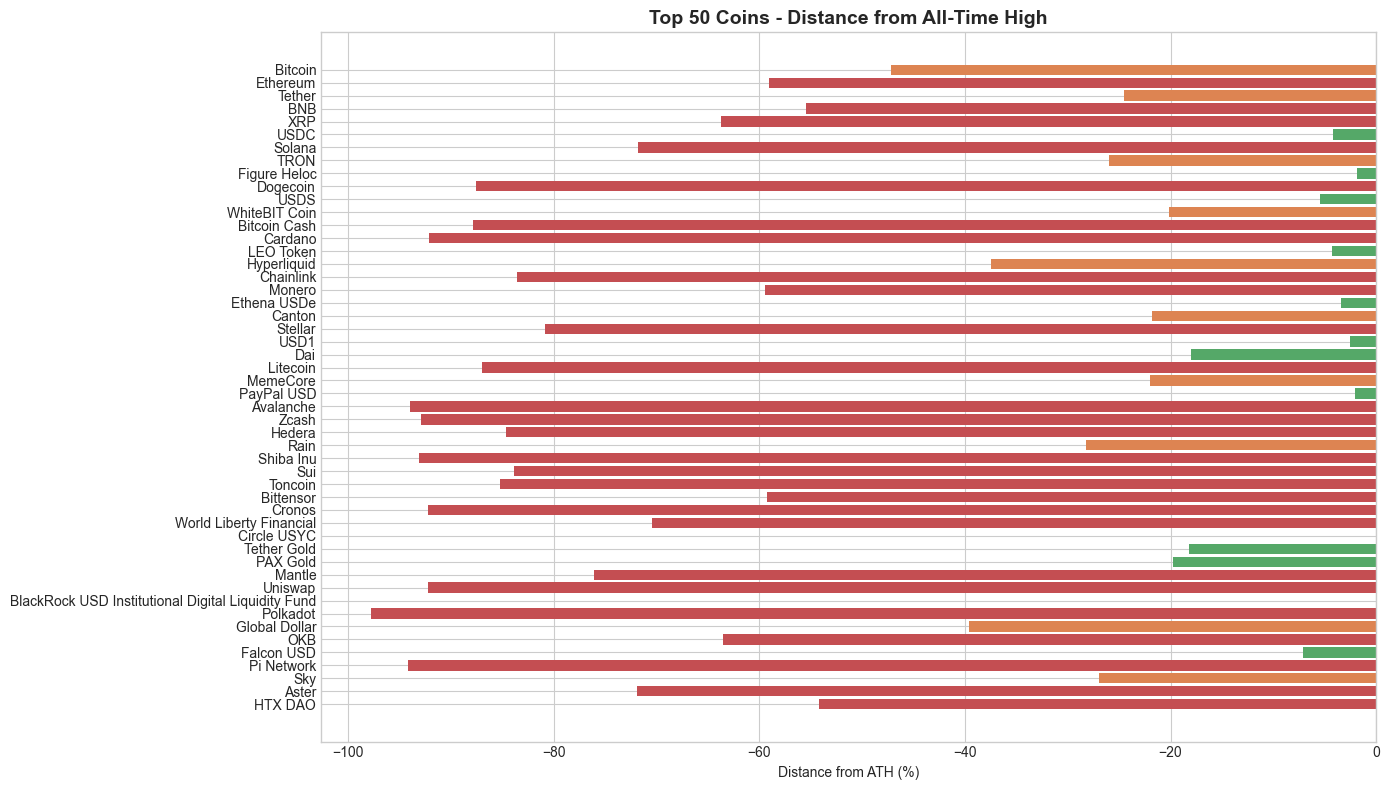

In [7]:
valid3 = df.dropna(subset=['ath_change_pct']).head(50)

fig, ax = plt.subplots(figsize=(14,8))
colors = ['#55A868' if x > -20 else '#DD8452' if x > -50 else '#C44E52' for x in valid3['ath_change_pct']]
ax.barh(valid3['name'][::-1], valid3['ath_change_pct'][::-1], color=colors[::-1])
ax.set_xlabel('Distance from ATH (%)'); ax.set_title('Top 50 Coins - Distance from All-Time High')
ax.axvline(x=0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig('../outputs/ath_distance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Market Tiers Analysis

                      count     total_mcap  avg_change  median_change  avg_vol_ratio
tier                                                                                
Large Cap (>$10B)        12  2132825753276        0.37           0.02           0.06
Mid Cap ($1-10B)         53   167109815607        0.56           0.03           0.05
Small Cap ($100M-1B)    185    56219680949        0.24           0.04           0.07


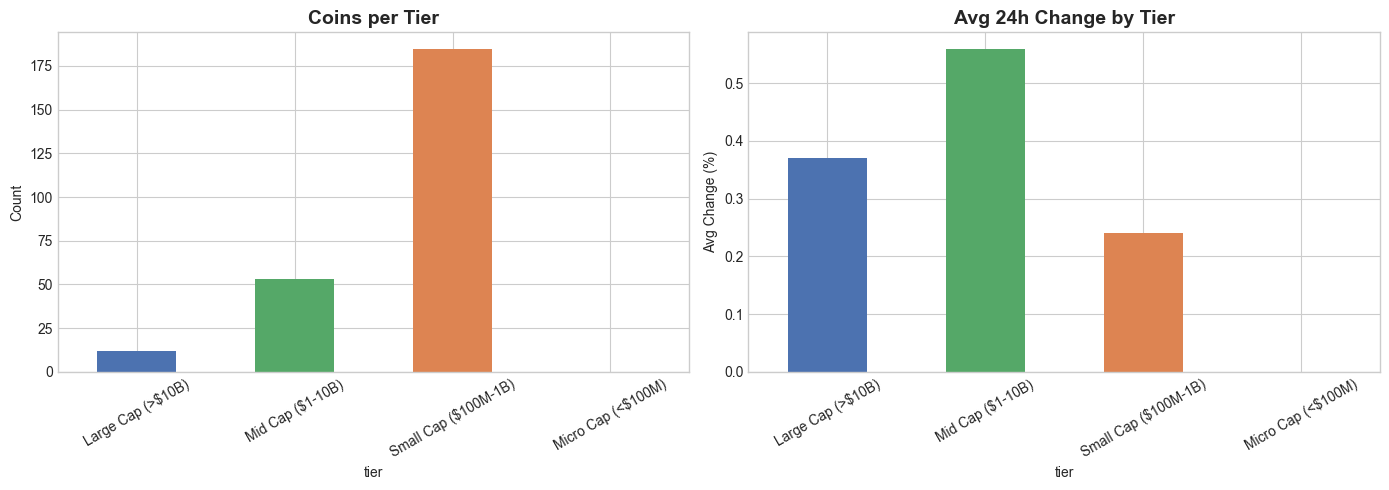

In [8]:
# Categorize by market cap tier
def tier(mcap):
    if mcap >= 10e9: return 'Large Cap (>$10B)'
    elif mcap >= 1e9: return 'Mid Cap ($1-10B)'
    elif mcap >= 100e6: return 'Small Cap ($100M-1B)'
    else: return 'Micro Cap (<$100M)'

df['tier'] = df['market_cap'].apply(tier)
tier_stats = df.groupby('tier').agg(
    count=('name','count'),
    total_mcap=('market_cap','sum'),
    avg_change=('price_change_pct_24h','mean'),
    median_change=('price_change_pct_24h','median'),
    avg_vol_ratio=('total_volume', lambda x: (x / df.loc[x.index, 'market_cap']).mean())
).round(2)

print(tier_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14,5))
tier_order = ['Large Cap (>$10B)', 'Mid Cap ($1-10B)', 'Small Cap ($100M-1B)', 'Micro Cap (<$100M)']
ts = tier_stats.reindex(tier_order)
ts['count'].plot(kind='bar', ax=axes[0], color=['#4C72B0','#55A868','#DD8452','#C44E52'])
axes[0].set_title('Coins per Tier'); axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=30)
ts['avg_change'].plot(kind='bar', ax=axes[1], color=['#4C72B0','#55A868','#DD8452','#C44E52'])
axes[1].set_title('Avg 24h Change by Tier'); axes[1].set_ylabel('Avg Change (%)'); axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig('../outputs/market_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Findings

1. **Bitcoin dominance** remains the key structural feature of the market
2. **Top 10 concentration** - the majority of market cap is in a handful of assets
3. **Volume follows market cap** on a log-log scale but with significant outliers (heavily traded vs thinly traded)
4. **Most coins are far from ATH** - showing the cyclical nature of the crypto market
5. **Smaller caps are more volatile** - micro caps show wider price swings in both directions
6. **Stablecoins** (USDT, USDC) show unique characteristics - high volume relative to market cap, near-zero price change

### Trading Insights
- Volume/market cap ratio can indicate liquidity and trading interest
- ATH distance can signal potential recovery candidates (or value traps)
- Tier-based analysis helps calibrate risk expectations

---
*Data sourced live from CoinGecko API*